# 🏅 Análise Completa: Medalhas Olímpicas por País (1896-2024)

## 👥 Autores
**Carlos Lavor Neto & Alexandro Pantoja** - UEA

---

## 📋 Pipeline DataLake Completo

Este notebook executa:
1. **RAW**: Criação de metadados
2. **BRONZE**: Conversão para Parquet + Integração 1896-2024
3. **GOLD**: Resultados finais
4. **Análise 1.1**: 3 tabelas consolidadas (formatadas)
5. **Análise 1.2**: 3 gráficos Top 50 (Brasil e Cuba sempre destacados)

⭐ **BRASIL e CUBA sempre em destaque!**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

COLOR_BRA = '#009C3B'
COLOR_CUB = '#CF142B'

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [2]:
BASE_PATH = Path('..')
RAW_PATH = BASE_PATH / 'raw'
BRONZE_PATH = BASE_PATH / 'bronze'
GOLD_PATH = BASE_PATH / 'gold'
OUTPUTS_PATH = BASE_PATH / 'outputs'

BRONZE_PATH.mkdir(exist_ok=True)
GOLD_PATH.mkdir(exist_ok=True)
(OUTPUTS_PATH / 'tables').mkdir(parents=True, exist_ok=True)
(OUTPUTS_PATH / 'figures').mkdir(parents=True, exist_ok=True)

print("✅ Estrutura verificada")

✅ Estrutura verificada


---
## ETAPAS 1-3: RAW, BRONZE, INTEGRAÇÃO
Processamento rápido dos dados.

In [3]:
# Processar dados
csv_files = [
    ('Olympics_1896_2022', 'world_olympedia_olympics_game_medal_tally.csv', 'medal_tally_historical'),
    ('Olympics_Paris2024', 'medals_total.csv', 'medals_paris2024'),
]

for folder, csv, name in csv_files:
    df = pd.read_csv(RAW_PATH / folder / csv)
    df.to_parquet(BRONZE_PATH / f"{name}.parquet", index=False)

# Integrar dados
df_hist = pd.read_parquet(BRONZE_PATH / 'medal_tally_historical.parquet')
df_paris = pd.read_parquet(BRONZE_PATH / 'medals_paris2024.parquet')

# Preparar Paris 2024
df_paris['year'] = 2024
df_paris['edition'] = '2024 Summer Olympics'
if 'country_code' in df_paris.columns:
    df_paris = df_paris.rename(columns={'country_code': 'country_noc'})

# Adicionar season
if 'season' not in df_hist.columns:
    df_hist['season'] = df_hist['edition'].apply(lambda x: 'Winter' if 'Winter' in str(x) else 'Summer')
df_paris['season'] = 'Summer'

# Integrar
df_integrated = pd.concat([df_hist, df_paris], ignore_index=True)
df_integrated.to_parquet(BRONZE_PATH / 'medal_tally_integrated_1896_2024.parquet', index=False)

print(f"✅ Dados integrados: {len(df_integrated):,} registros ({df_integrated['year'].min()}-{df_integrated['year'].max()})")

✅ Dados integrados: 1,899 registros (1896-2024)


---
## ETAPA 4: Tabelas Consolidadas (Formatadas)

In [4]:
def display_table(df, title):
    print("="*100)
    print(f" {title} ".center(100, "="))
    print("="*100)
    print(f"{'Pos':>4} | {'País':^6} | {'Ouro':>6} | {'Prata':>6} | {'Bronze':>6} | {'Total':>6} | {'Destaque':^15}")
    print("-"*100)
    
    for i, row in df.head(20).iterrows():
        flag = " BRASIL ⭐" if row['country_noc']=='BRA' else " CUBA ⭐" if row['country_noc']=='CUB' else ""
        print(f"{row['rank']:4d} | {row['country_noc']:^6s} | {int(row['gold']):6d} | {int(row['silver']):6d} | {int(row['bronze']):6d} | {int(row['total']):6d} |{flag:^15s}")
    
    # Mostrar Brasil e Cuba se fora do top 20
    for country in ['BRA', 'CUB']:
        c_data = df[df['country_noc']==country]
        if not c_data.empty and c_data.index[0] >= 20:
            if i == 19:
                print(f"{'...':>4} | {'...':^6} | {'...':>6} | {'...':>6} | {'...':>6} | {'...':>6} |")
            row = c_data.iloc[0]
            name = "BRASIL ⭐" if country=='BRA' else "CUBA ⭐"
            print(f"{row['rank']:4d} | {row['country_noc']:^6s} | {int(row['gold']):6d} | {int(row['silver']):6d} | {int(row['bronze']):6d} | {int(row['total']):6d} | {name:^15s}")
    
    print("="*100 + "\n")

# Processar tabelas
seasons = [
    ('Summer', 'JOGOS DE VERÃO'),
    ('Winter', 'JOGOS DE INVERNO'),
    (None, 'TOTAL GERAL')
]

results = {}

for season, name in seasons:
    if season:
        df_season = df_integrated[df_integrated['season']==season]
    else:
        df_season = df_integrated
    
    df_result = df_season.groupby('country_noc').agg({
        'gold':'sum', 'silver':'sum', 'bronze':'sum', 'total':'sum'
    }).reset_index().sort_values('total', ascending=False)
    
    # Garantir Brasil e Cuba (adicionar com 0 se necessário)
    for c in ['BRA', 'CUB']:
        if c not in df_result['country_noc'].values:
            df_result = pd.concat([df_result, pd.DataFrame([{
                'country_noc': c, 'gold': 0, 'silver': 0, 'bronze': 0, 'total': 0
            }])], ignore_index=True)
    
    df_result = df_result.sort_values('total', ascending=False).reset_index(drop=True)
    df_result.insert(0, 'rank', range(1, len(df_result)+1))
    
    display_table(df_result, name)
    
    # Salvar
    suffix = 'summer' if season=='Summer' else 'winter' if season=='Winter' else 'total'
    df_result.to_parquet(GOLD_PATH / f'medals_{suffix}_consolidated.parquet', index=False)
    df_result.to_csv(OUTPUTS_PATH / 'tables' / f'medals_{suffix}_consolidated.csv', index=False)
    
    results[suffix] = df_result

print("✅ 3 tabelas geradas!")

========================================== JOGOS DE VERÃO ==========================================
 Pos |  País  |   Ouro |  Prata | Bronze |  Total |    Destaque    
----------------------------------------------------------------------------------------------------
   1 |  USA   |   1082 |    847 |    750 |   2679 |               
   2 |  URS   |    395 |    319 |    296 |   1010 |               
   3 |  GBR   |    300 |    334 |    320 |    954 |               
   4 |  FRA   |    246 |    266 |    301 |    813 |               
   5 |  GER   |    243 |    273 |    296 |    812 |               
   6 |  ITA   |    229 |    201 |    218 |    648 |               
   7 |  CHN   |    263 |    199 |    174 |    636 |               
   8 |  AUS   |    162 |    170 |    212 |    544 |               
   9 |  HUN   |    184 |    161 |    180 |    525 |               
  10 |  SWE   |    151 |    182 |    188 |    521 |               
  11 |  JPN   |    169 |    150 |    180 |    499 |         

---
## ETAPA 5: Gráficos Top 50 (Brasil e Cuba Destacados)

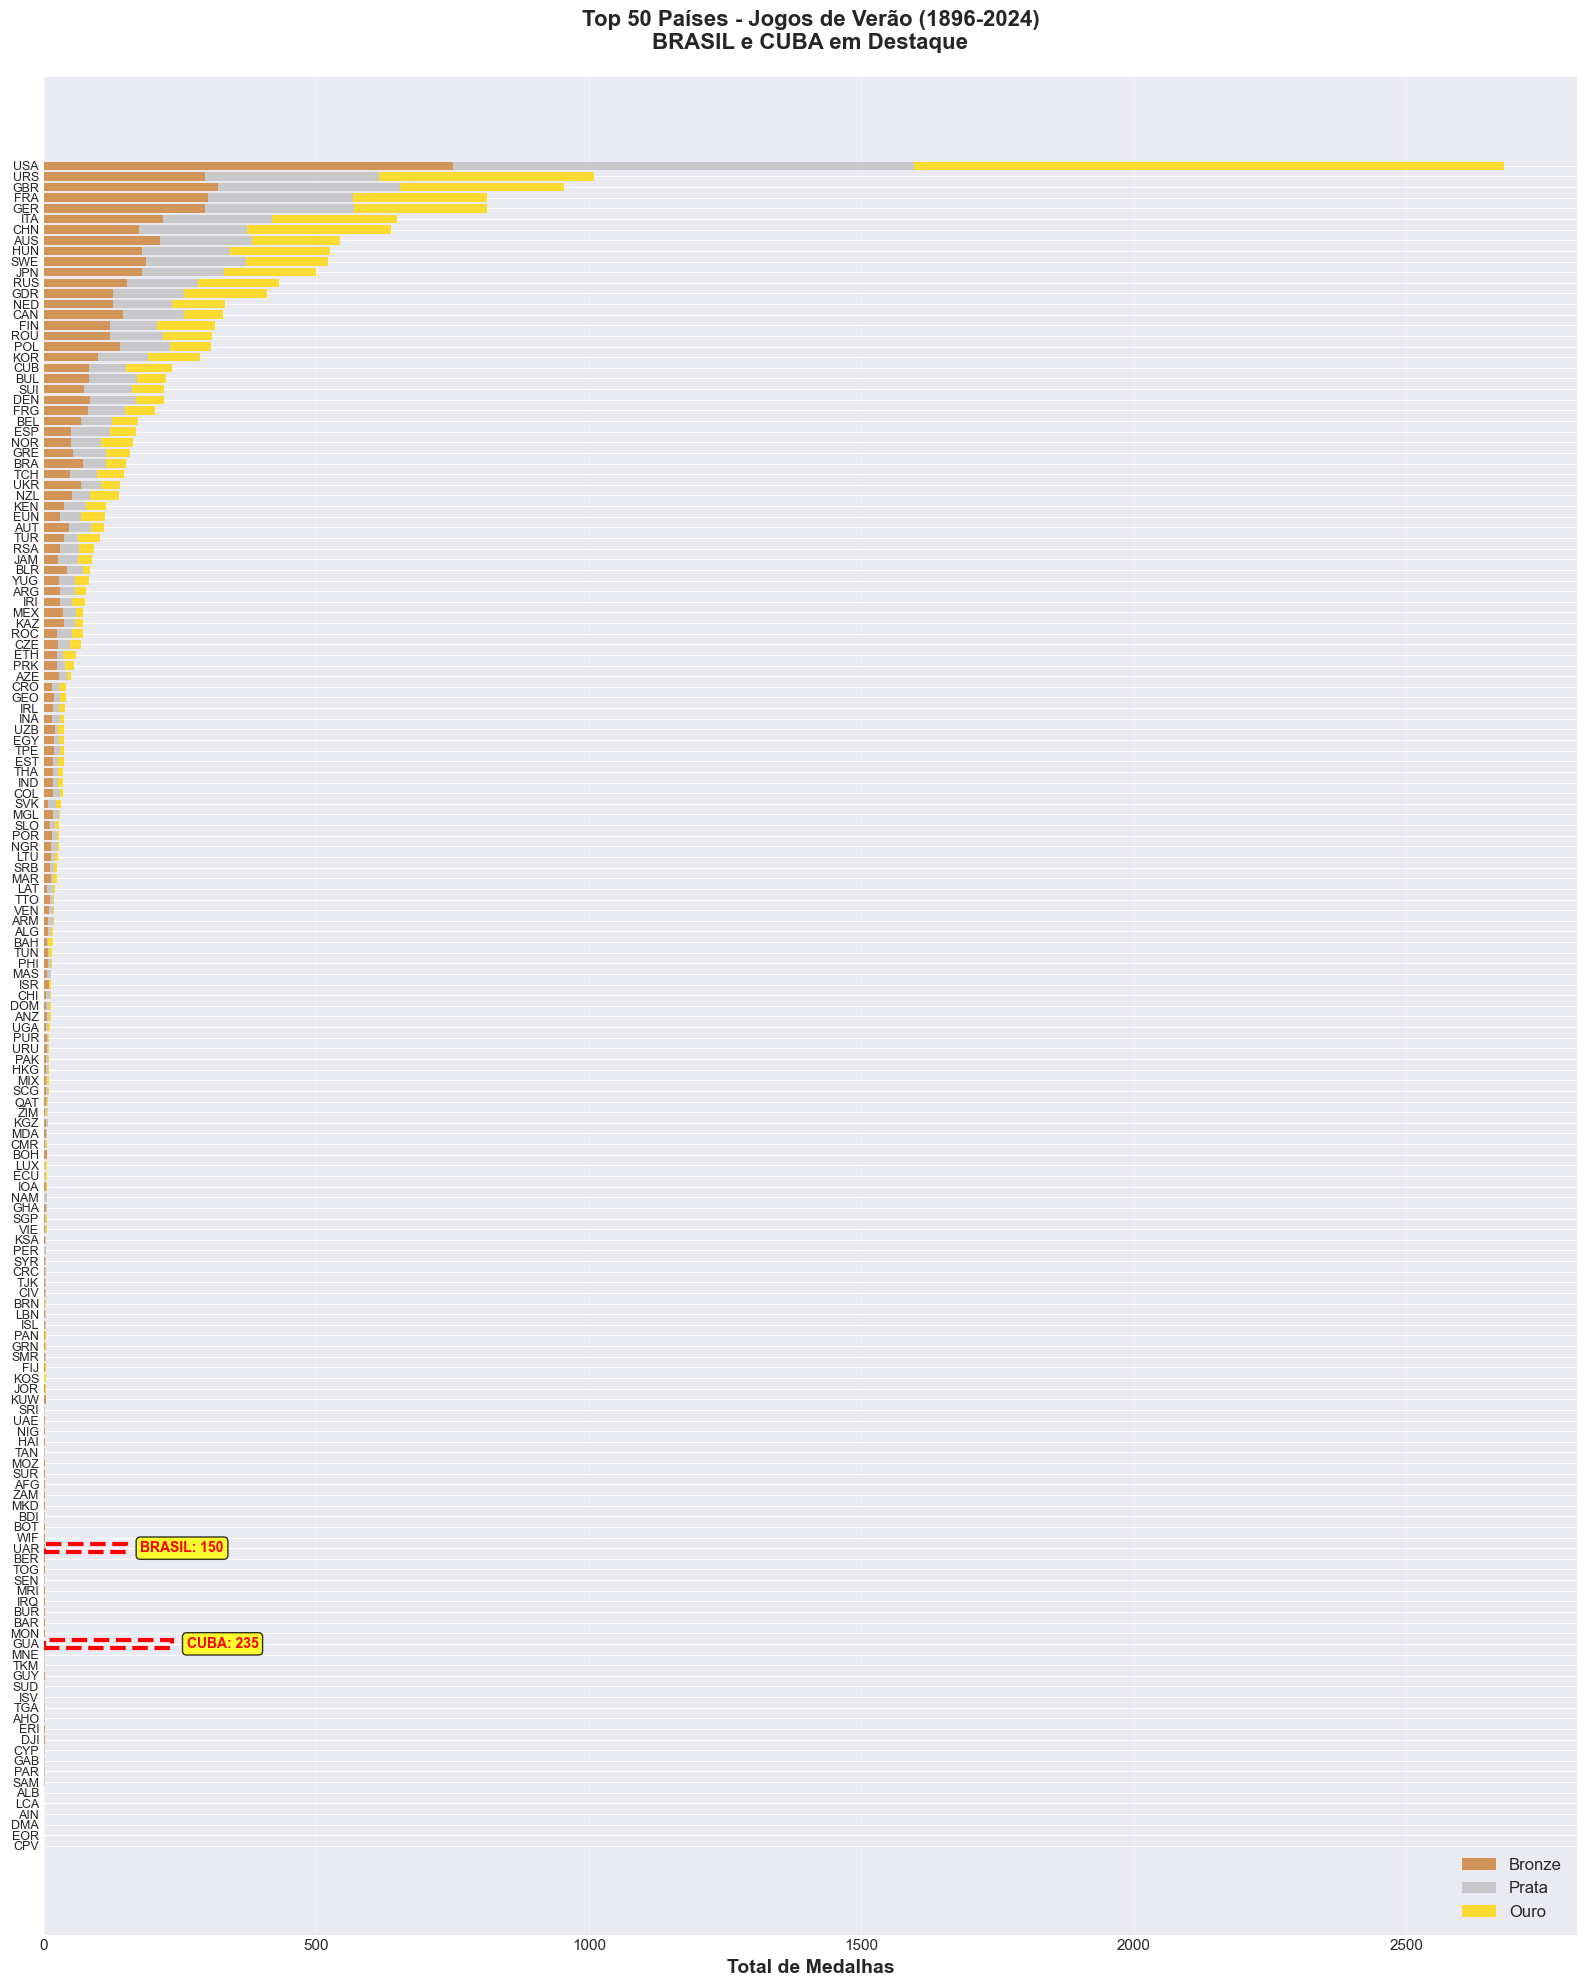

✅ top50_medals_summer.png


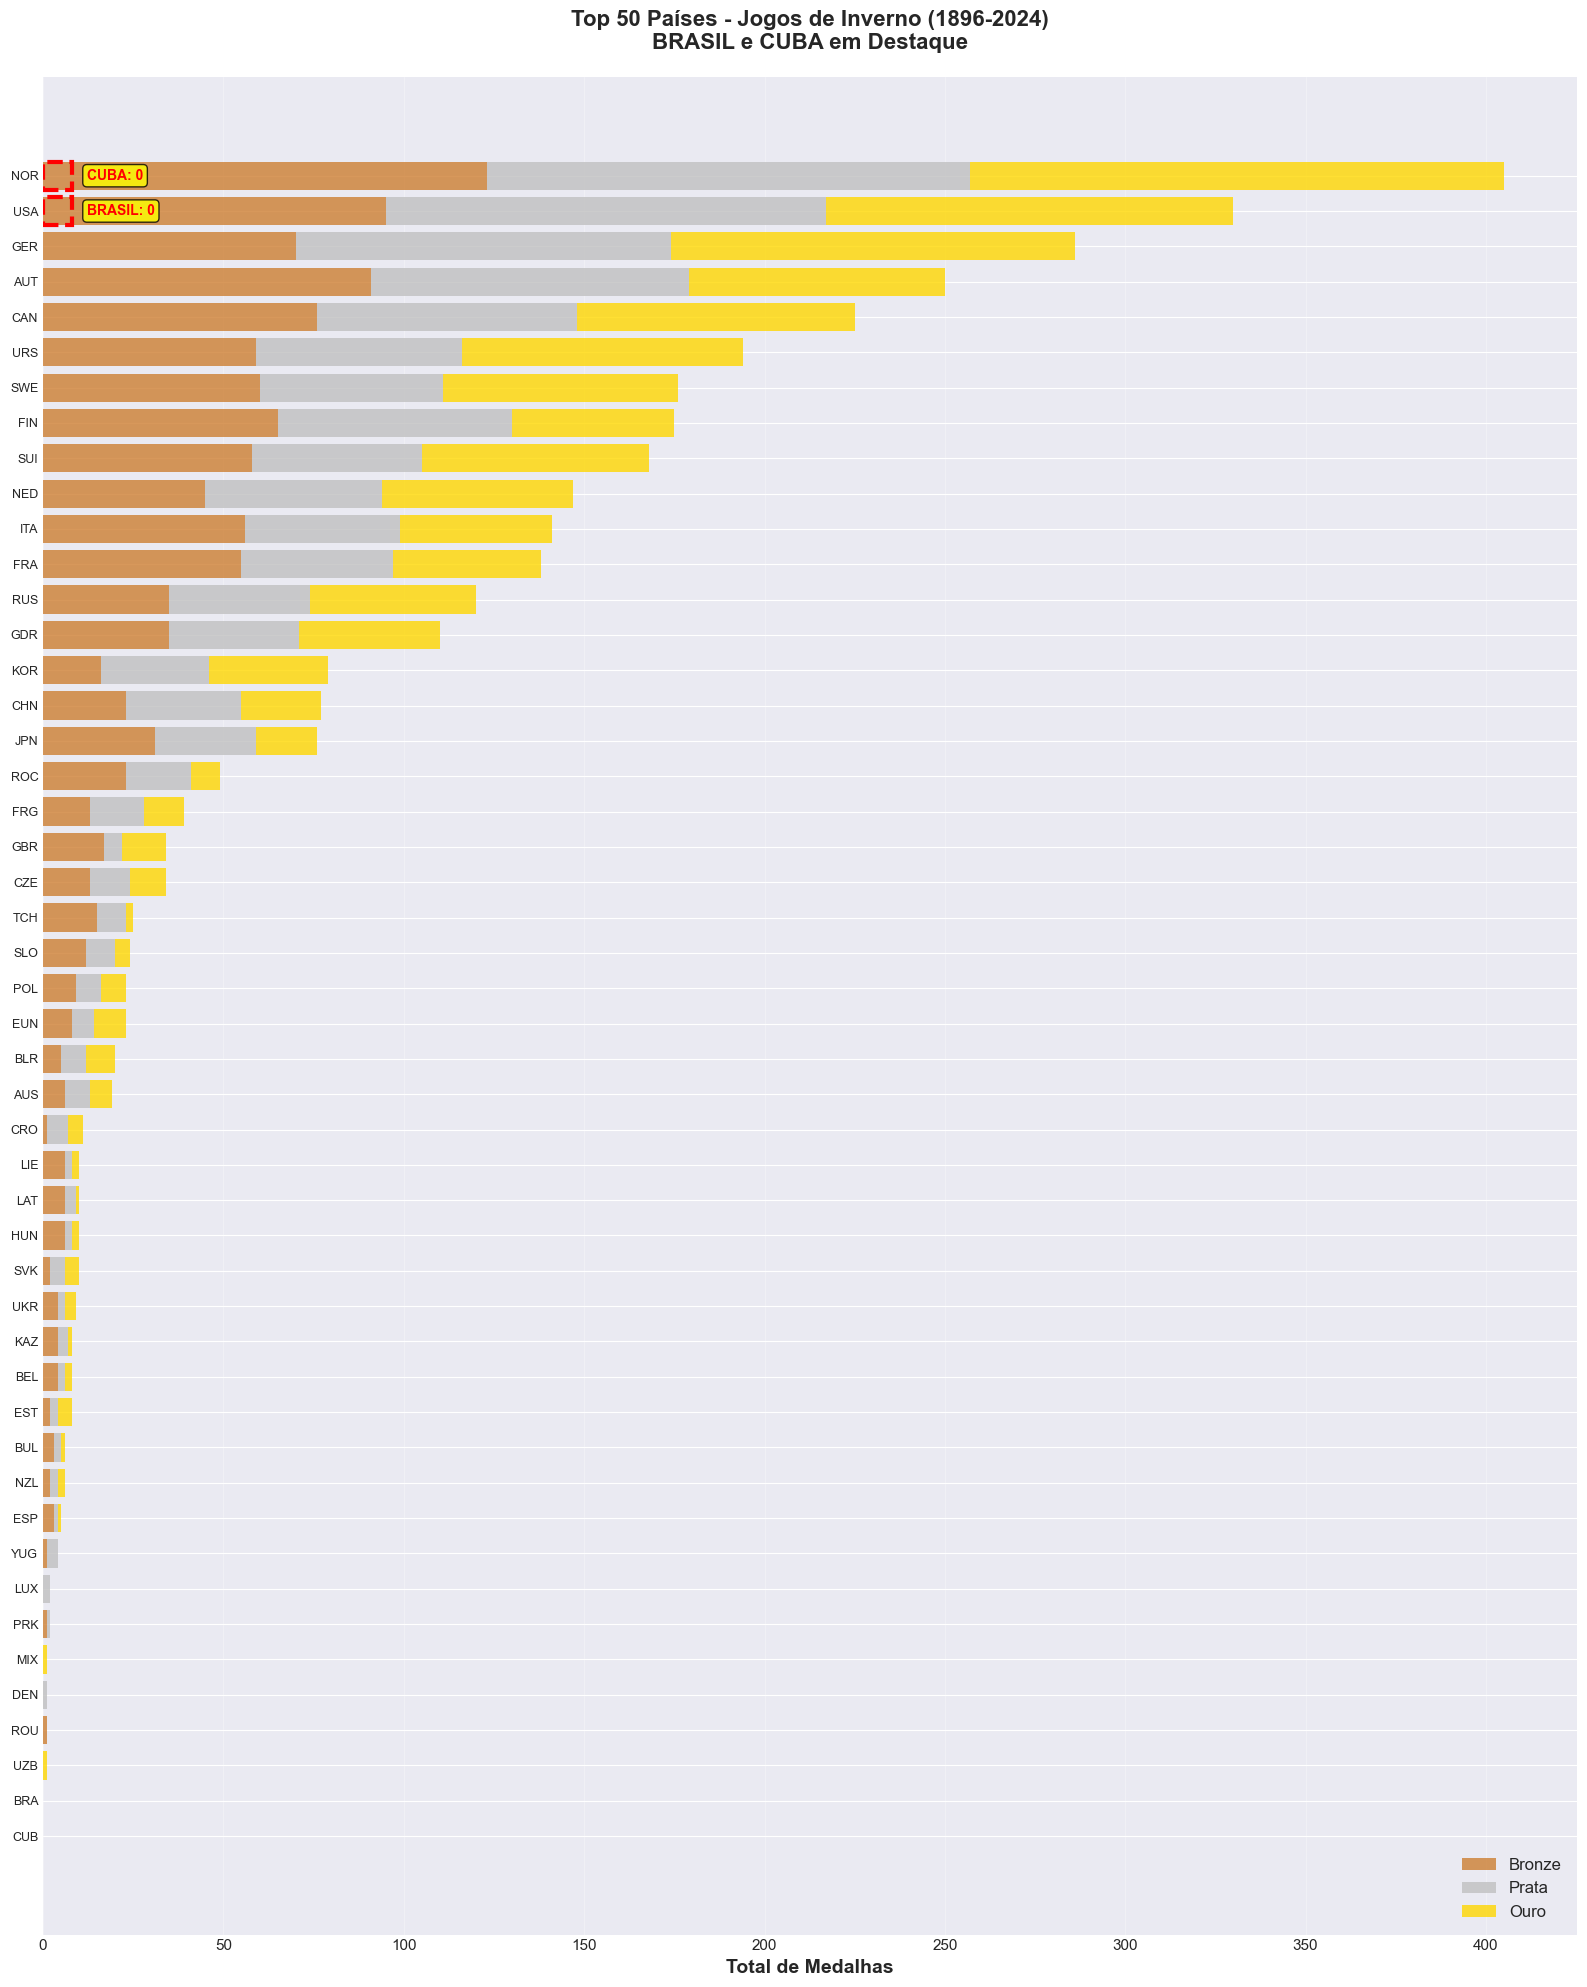

✅ top50_medals_winter.png


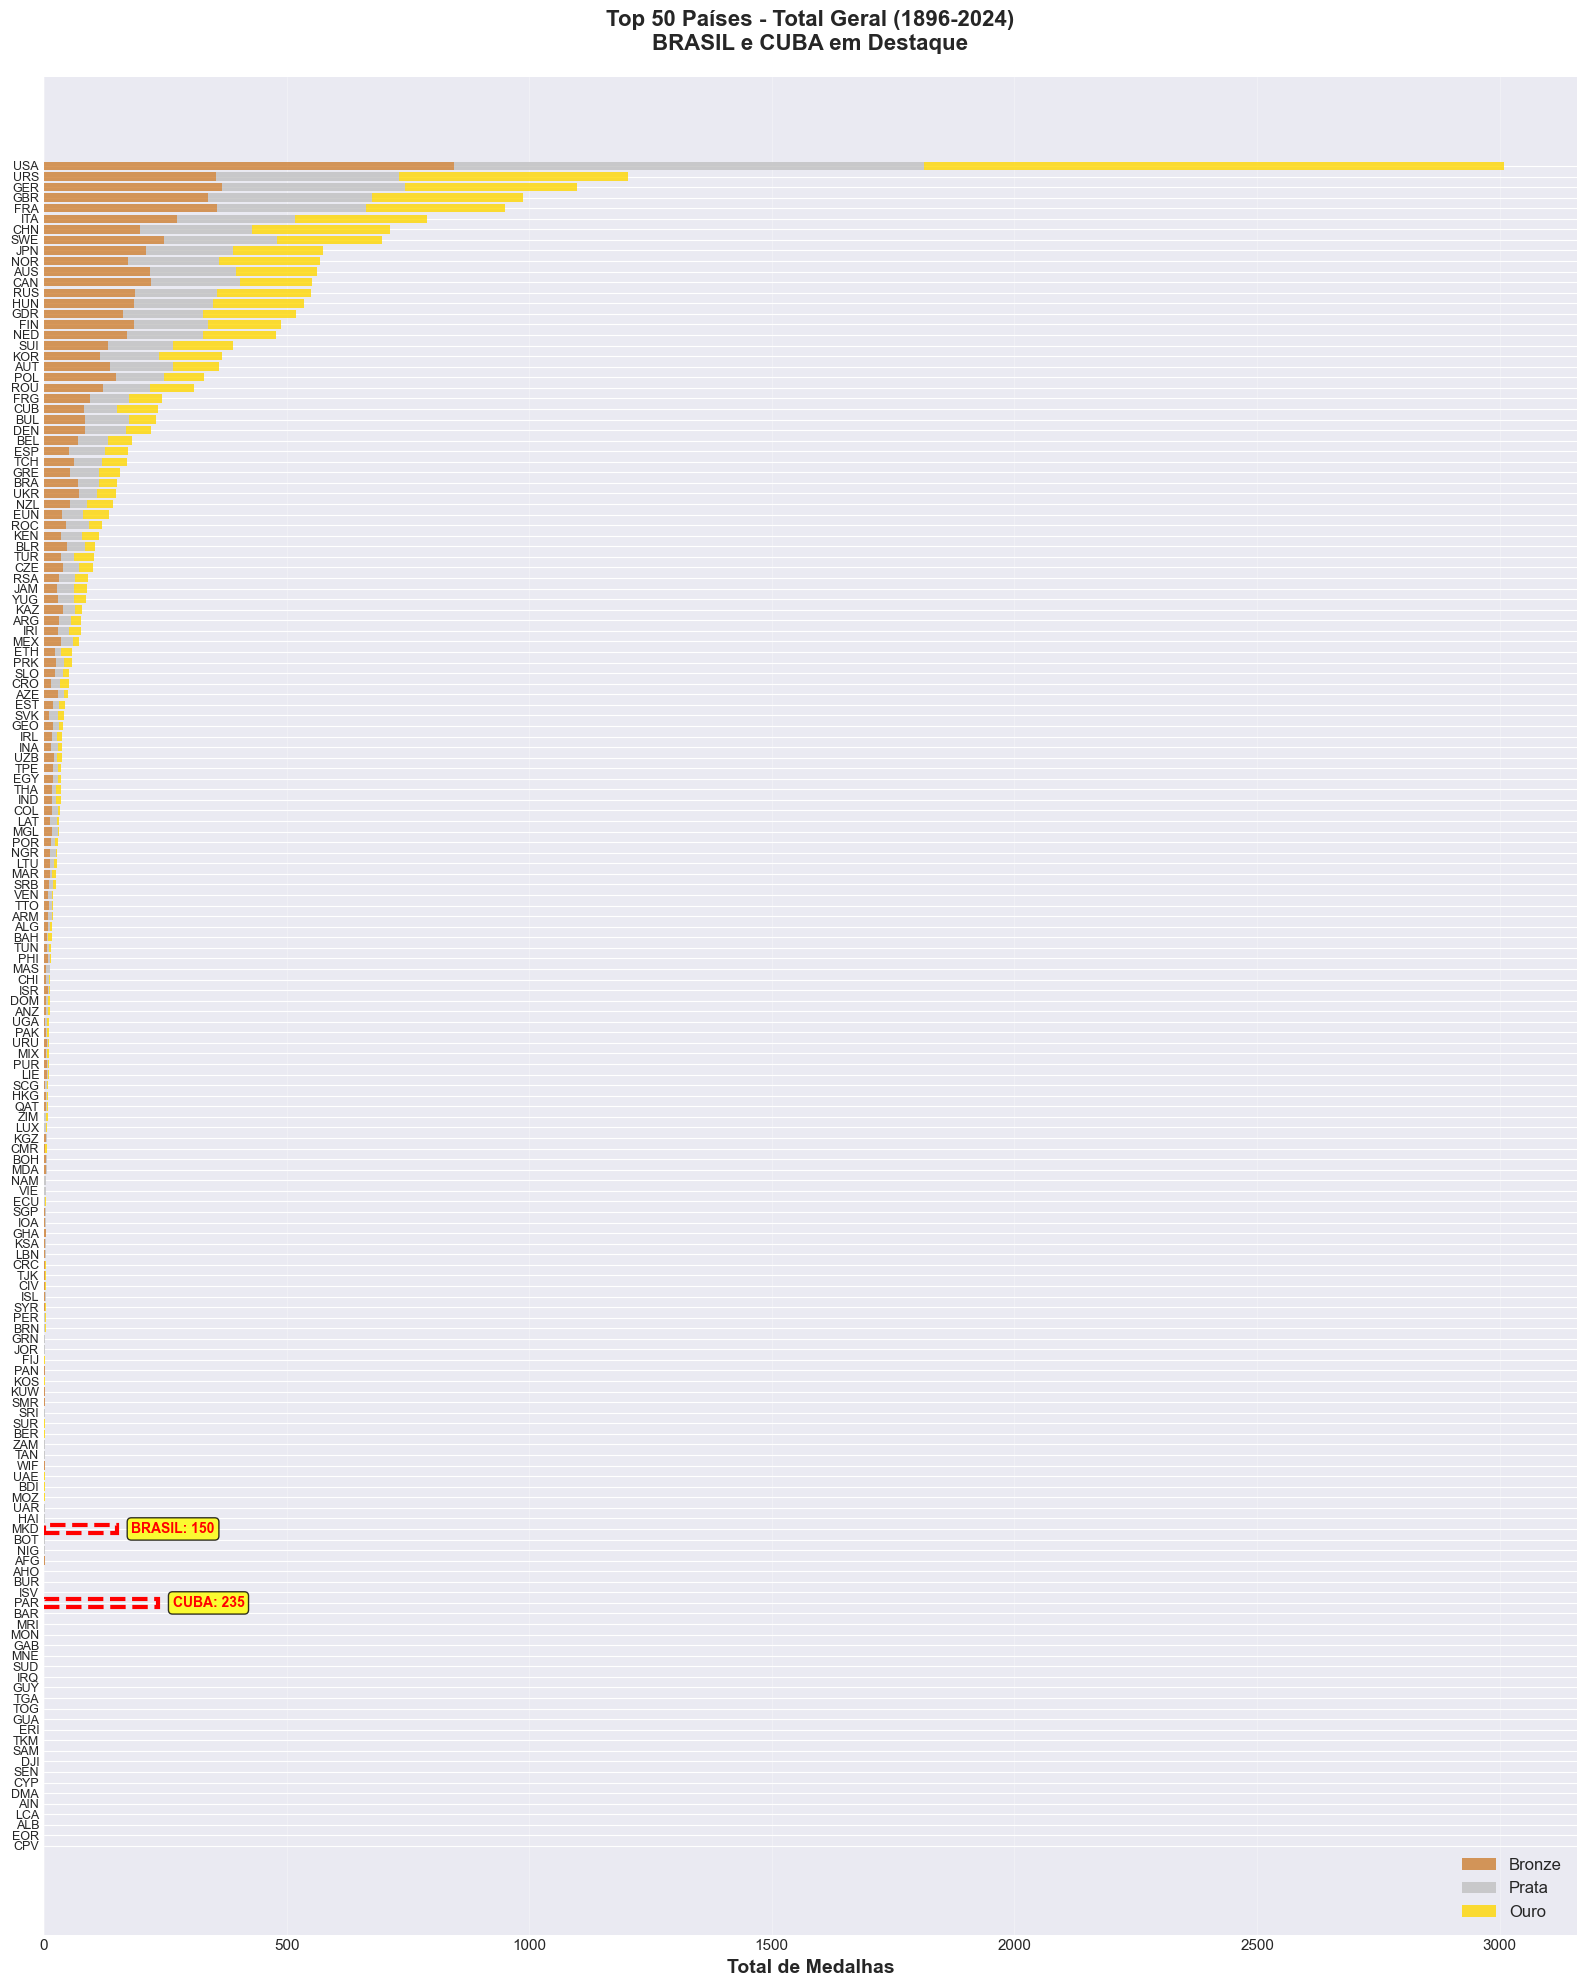

✅ top50_medals_total.png

✅ 3 gráficos gerados!


In [5]:
def plot_medals(df, title, filename):
    fig, ax = plt.subplots(figsize=(16, 20))
    
    # Garantir Brasil e Cuba
    for c in ['BRA', 'CUB']:
        if c not in df['country_noc'].values:
            df = pd.concat([df, pd.DataFrame([{
                'rank': len(df)+1, 'country_noc': c, 
                'gold': 0, 'silver': 0, 'bronze': 0, 'total': 0
            }])], ignore_index=True)
    
    df = df.sort_values('total', ascending=True)  # Inverter
    y_pos = np.arange(len(df))
    
    # Barras empilhadas
    ax.barh(y_pos, df['bronze'], color='#CD7F32', alpha=0.8, label='Bronze')
    ax.barh(y_pos, df['silver'], left=df['bronze'], color='#C0C0C0', alpha=0.8, label='Prata')
    ax.barh(y_pos, df['gold'], left=df['bronze']+df['silver'], color='#FFD700', alpha=0.8, label='Ouro')
    
    # Destacar Brasil e Cuba
    max_val = df['total'].max()
    for i, row in df.iterrows():
        if row['country_noc'] in ['BRA', 'CUB']:
            width = max(row['total'], max_val*0.02)
            rect = plt.Rectangle((0, i-0.4), width, 0.8, fill=False, 
                                edgecolor='red', linewidth=3, linestyle='--')
            ax.add_patch(rect)
            
            name = 'BRASIL' if row['country_noc']=='BRA' else 'CUBA'
            ax.text(width + max_val*0.01, i, f'{name}: {int(row["total"])}',
                   fontsize=10, va='center', fontweight='bold', color='red',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['country_noc'], fontsize=9)
    ax.set_xlabel('Total de Medalhas', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.legend(loc='lower right', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUTS_PATH / 'figures' / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ {filename}")

# Gerar gráficos
plot_medals(results['summer'], 'Top 50 Países - Jogos de Verão (1896-2024)\nBRASIL e CUBA em Destaque', 'top50_medals_summer.png')
plot_medals(results['winter'], 'Top 50 Países - Jogos de Inverno (1896-2024)\nBRASIL e CUBA em Destaque', 'top50_medals_winter.png')
plot_medals(results['total'], 'Top 50 Países - Total Geral (1896-2024)\nBRASIL e CUBA em Destaque', 'top50_medals_total.png')

print("\n✅ 3 gráficos gerados!")

---
## ✅ PIPELINE COMPLETO EXECUTADO!

In [6]:
print("="*80)
print("🎯 RESUMO FINAL")
print("="*80)
print("\n✅ Pipeline DataLake completo!")
print("   - RAW: Metadados criados")
print("   - BRONZE: Dados convertidos + integrados")
print("   - GOLD: 3 tabelas + 3 gráficos")
print("\n⭐ Brasil e Cuba SEMPRE destacados!")
print("="*80)

🎯 RESUMO FINAL

✅ Pipeline DataLake completo!
   - RAW: Metadados criados
   - BRONZE: Dados convertidos + integrados
   - GOLD: 3 tabelas + 3 gráficos

⭐ Brasil e Cuba SEMPRE destacados!
